# Length Scale Constraint

When data is deficient, quantiles are likely to overfit.
This can be mitigated by setting lower bounds to kernel length scales.

In [ ]:
import os

import torch
from gpytorch.constraints import Interval
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy
from gpytorch.means import ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.means import CenterGapMean
from gpytorch_qr.models import CenterGapQuantileGP
from gpytorch_qr.variational import CGLmcVariationalStrategy
from gpytorch_qr.likelihoods import CenterGapQuantileLikelihood

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 10000))

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x[..., 0] * 2 * 3.14) * torch.cos(x[..., 1] * 2 * 3.14)


def std(x):
    return x[..., 0] + x[..., 1] + 0.1


x2_values = torch.tensor([0.1, 0.5, 0.9]).to(device)
n_per_x2 = 20
x = torch.stack(
    [
        torch.rand(n_per_x2 * len(x2_values)).to(device),
        x2_values.repeat_interleave(n_per_x2),
    ],
    dim=1,
)

y = (mean(x) + torch.randn(x.shape[0], device=device).mul(std(x))).squeeze()

q = torch.tensor([0.1, 0.5, 0.9]).to(device)

In [ ]:
x1_pred = torch.linspace(0, 1, 100).to(device)
x_pred = torch.stack(
    [
        x1_pred.unsqueeze(0).expand(len(x2_values), -1),
        x2_values.unsqueeze(1).expand(-1, len(x1_pred)),
    ],
    dim=-1,
)  # *(X1, X2, D)

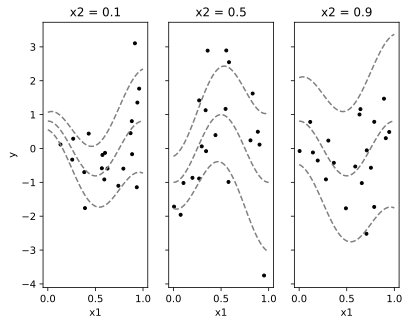

In [ ]:
fig, axes = plt.subplots(1, len(x2_values), sharey=True)

for i, x2_val in enumerate(x2_values):
    ax = axes[i]

    mask = x[:, 1] == x2_val
    ax.scatter(x[mask, 0].cpu(), y[mask].cpu(), c="k", marker=".")

    x_line = x_pred[i]
    true_q_lines = mean(x_line).unsqueeze(-1) + std(x_line).unsqueeze(-1) * Normal(
        0, 1
    ).icdf(q)
    ax.plot(x_line[..., 0].cpu(), true_q_lines.cpu(), "--", color="gray")

    ax.set_title(f"x2 = {x2_val:.1f}")
    ax.set_xlabel("x1")
    if i == 0:
        ax.set_ylabel("y")

plt.show()

## Without constraint

In [ ]:
class MyGP_NoConstraint(CenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
    ):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = CGLmcVariationalStrategy(
            VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles,
            num_latents,
            num_quantiles=[num_quantiles],
            num_lower_quantiles=[num_lower_quantiles],
        )

        mean = CenterGapMean(
            ConstantMean(batch_shape=torch.Size([1])),
            ConstantMean(batch_shape=torch.Size([num_latents - 1])),
        )
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(
            variational_strategy, mean, covar, [num_quantiles], [num_lower_quantiles]
        )


g1, g2 = torch.meshgrid(
    torch.linspace(0, 1, 10),
    torch.tensor([0.1, 0.3, 0.5, 0.7, 0.9]),
    indexing="ij",
)
inducing_points = torch.stack([g1.flatten(), g2.flatten()], dim=1).to(device)
central_q_index = (q - 0.5).abs().argmin().item()
num_latents = len(q)
gp_noconstraint = MyGP_NoConstraint(
    inducing_points, len(q), central_q_index, num_latents
).to(device)
likelihood_noconstraint = CenterGapQuantileLikelihood(q, central_q_index).to(device)

In [ ]:
gp_noconstraint.train()
likelihood_noconstraint.train()
mll = VariationalELBO(likelihood_noconstraint, gp_noconstraint, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp_noconstraint.parameters()) + list(likelihood_noconstraint.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp_noconstraint(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
gp_noconstraint.eval()
with torch.no_grad():
    mean_q_noconstraint = gp_noconstraint.mean_quantiles_mc(
        x_pred.flatten(0, -2), 1
    ).unflatten(-2, x_pred.shape[:-1])

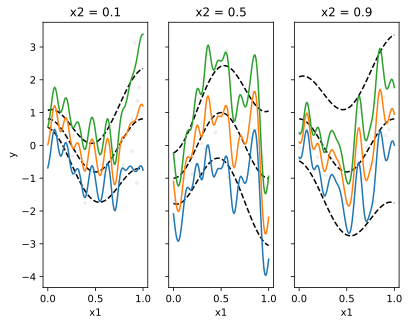

In [ ]:
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(x2_values), sharey=True)

for i, x2_val in enumerate(x2_values):
    ax = axes[i]

    mask = x[:, 1] == x2_val
    ax.scatter(x[mask, 0].cpu(), y[mask].cpu(), c="gray", marker=".", alpha=0.1)

    x_line = x_pred[i]
    true_q_lines = mean(x_line).unsqueeze(-1) + std(x_line).unsqueeze(-1) * Normal(
        0, 1
    ).icdf(q)

    ax.plot(x_line[..., 0].cpu(), true_q_lines.cpu(), "--", color="k")

    for j in range(len(q)):
        ax.plot(
            x_line[..., 0].cpu(), mean_q_noconstraint[i, ..., j].cpu(), color=colors[j]
        )

    ax.set_title(f"x2 = {x2_val:.1f}")
    ax.set_xlabel("x1")
    if i == 0:
        ax.set_ylabel("y")

plt.show()

## With constraint

In [ ]:
class MyGP_Constraint(CenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
    ):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = CGLmcVariationalStrategy(
            VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles,
            num_latents,
            num_quantiles=[num_quantiles],
            num_lower_quantiles=[num_lower_quantiles],
        )

        mean = CenterGapMean(
            ConstantMean(batch_shape=torch.Size([1])),
            ConstantMean(batch_shape=torch.Size([num_latents - 1])),
        )
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents]),
        )

        lower_constraint = torch.tensor([0.2, 0])
        upper_constraint = torch.tensor([1e2, 1e2])
        initial_lengthscale = torch.tensor([0.5, 0.5])
        covar.base_kernel.register_constraint(
            "raw_lengthscale", Interval(lower_constraint, upper_constraint)
        )
        with torch.no_grad():
            covar.base_kernel.lengthscale = initial_lengthscale

        super().__init__(
            variational_strategy, mean, covar, [num_quantiles], [num_lower_quantiles]
        )


g1, g2 = torch.meshgrid(
    torch.linspace(0, 1, 10),
    torch.tensor([0.1, 0.3, 0.5, 0.7, 0.9]),
    indexing="ij",
)
inducing_points = torch.stack([g1.flatten(), g2.flatten()], dim=1).to(device)
central_q_index = (q - 0.5).abs().argmin().item()
num_latents = len(q)
gp_constraint = MyGP_Constraint(
    inducing_points, len(q), central_q_index, num_latents
).to(device)
likelihood_constraint = CenterGapQuantileLikelihood(q, central_q_index).to(device)

In [ ]:
gp_constraint.train()
likelihood_constraint.train()
mll = VariationalELBO(likelihood_constraint, gp_constraint, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp_constraint.parameters()) + list(likelihood_constraint.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp_constraint(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
gp_constraint.eval()
with torch.no_grad():
    mean_q_constraint = gp_constraint.mean_quantiles_mc(
        x_pred.flatten(0, -2), 1
    ).unflatten(-2, x_pred.shape[:-1])

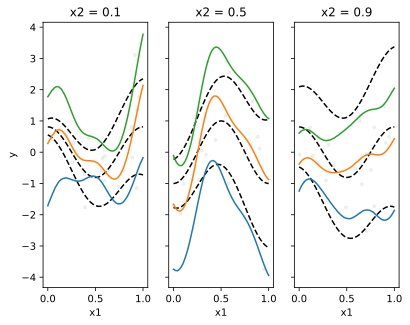

In [ ]:
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(x2_values), sharey=True)

for i, x2_val in enumerate(x2_values):
    ax = axes[i]

    mask = x[:, 1] == x2_val
    ax.scatter(x[mask, 0].cpu(), y[mask].cpu(), c="gray", marker=".", alpha=0.1)

    x_line = x_pred[i]
    true_q_lines = mean(x_line).unsqueeze(-1) + std(x_line).unsqueeze(-1) * Normal(
        0, 1
    ).icdf(q)

    ax.plot(x_line[..., 0].cpu(), true_q_lines.cpu(), "--", color="k")

    for j in range(len(q)):
        ax.plot(
            x_line[..., 0].cpu(), mean_q_constraint[i, ..., j].cpu(), color=colors[j]
        )

    ax.set_title(f"x2 = {x2_val:.1f}")
    ax.set_xlabel("x1")
    if i == 0:
        ax.set_ylabel("y")

plt.show()